# TP : Classification Supervisée avec Scikit-Learn (Dataset Titanic)

Ce notebook est un guide d'introduction au Machine Learning pour les débutants. Nous allons suivre toutes les étapes clés d'un projet de classification, du chargement des données jusqu'à l'évaluation et la prédiction sur de nouvelles observations.

---

## 1. Importation des bibliothèques

Pour commencer, nous devons importer les bibliothèques standards pour la manipulation de données (`pandas`, `numpy`), la visualisation graphique (`matplotlib`, `seaborn`) et les composants clés de `scikit-learn` pour le Machine Learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importations Scikit-Learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## 2. Chargement des données

Nous allons charger le jeu de données public du Titanic hébergé sur GitHub. Nous afficherons un aperçu des premières lignes (`head()`), les dimensions du tableau (`shape`), la liste des colonnes (`columns`) et les types de données (`dtypes`).

In [3]:
# URL du dataset public Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Chargement direct
df = pd.read_csv(url)

# Affichage des informations de base
print(f"Dimensions du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")
print("Types de données par colonne :")
print(df.dtypes)
print("\nAperçu des 5 premières lignes du dataset :")
display(df.head())

Dimensions du dataset : 891 lignes et 12 colonnes

Types de données par colonne :
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Aperçu des 5 premières lignes du dataset :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Analyse exploratoire des données

Avant de manipuler nos données, il est crucial de comprendre leur structure. Nous allons générer des statistiques descriptives (`describe()`), identifier les valeurs manquantes et explorer graphiquement les taux de survie selon différentes variables explicatives.

Statistiques descriptives :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN



Nombre de valeurs manquantes par colonne :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Distribution de la survie :
- Décédés (0) : 61.62%
- Survivants (1) : 38.38%


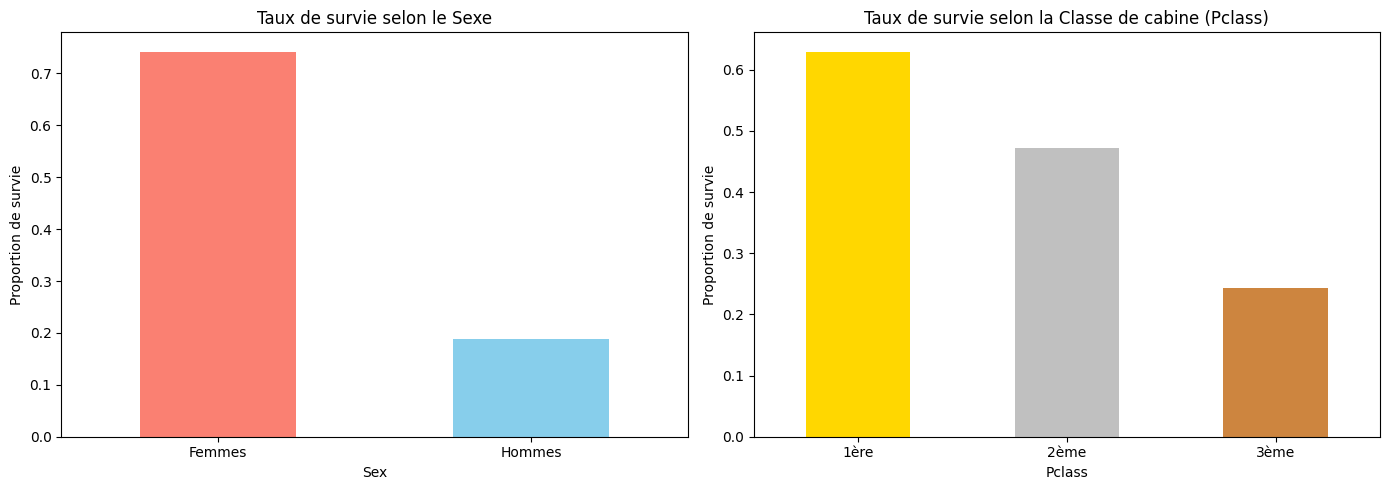

In [4]:
# 1. Statistiques descriptives
print("Statistiques descriptives :")
display(df.describe(include='all'))

# 2. Vérification des valeurs manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 3. Distribution de la variable cible (Survived)
survived_counts = df['Survived'].value_counts(normalize=True) * 100
print(f"\nDistribution de la survie :\n- Décédés (0) : {survived_counts[0]:.2f}%\n- Survivants (1) : {survived_counts[1]:.2f}%")

# 4. Visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Taux de survie par Sexe
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['salmon', 'skyblue'])
axes[0].set_title("Taux de survie selon le Sexe")
axes[0].set_ylabel("Proportion de survie")
axes[0].set_xticklabels(["Femmes", "Hommes"], rotation=0)

# Graphique 2 : Taux de survie par Classe de ticket
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'peru'])
axes[1].set_title("Taux de survie selon la Classe de cabine (Pclass)")
axes[1].set_ylabel("Proportion de survie")
axes[1].set_xticklabels(["1ère", "2ème", "3ème"], rotation=0)

plt.tight_layout()
plt.show()

## 4. Définition de X (caractéristiques) et y (cible)

Nous allons isoler la cible à prédire $y$ (`Survived`) de nos caractéristiques (features) explicatives $X$. Nous sélectionnons un sous-ensemble cohérent de variables explicatives :
- `Pclass` (Classe de cabine)
- `Sex` (Genre)
- `Age` (Âge du passager)
- `SibSp` (Nombre de frères/sœurs/conjoints à bord)
- `Parch` (Nombre de parents/enfants à bord)
- `Fare` (Tarif du ticket)
- `Embarked` (Port d'embarquement)

In [5]:
# Choix des colonnes explicatives
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features].copy()
y = df['Survived'].copy()

print("Dimensions de la matrice des caractéristiques X :", X.shape)
print("Dimensions du vecteur cible y :", y.shape)

Dimensions de la matrice des caractéristiques X : (891, 7)
Dimensions du vecteur cible y : (891,)


## 5. Prétraitement des données

Pour que notre modèle fonctionne correctement, nous devons traiter les données :
1. **Valeurs manquantes** : Remplacer l'âge manquant par la valeur médiane, et le port d'embarquement par sa valeur la plus fréquente (le mode).
2. **Encodage** : Convertir les colonnes textuelles (`Sex`, `Embarked`) en variables numériques compréhensibles par les algorithmes mathématiques via le One-Hot Encoding (`pd.get_dummies`).
3. **Mise à l'échelle (Scaling)** : Nous appliquerons ultérieurement la normalisation sur les ensembles d'entraînement et de test pour éviter que les variables à grande échelle (comme `Fare`) ne dominent le modèle.

In [6]:
# 1. Imputation des valeurs manquantes
age_median = X['Age'].median()
embarked_mode = X['Embarked'].mode()[0]

X['Age'] = X['Age'].fillna(age_median)
X['Embarked'] = X['Embarked'].fillna(embarked_mode)

# 2. Encodage des variables catégorielles (Sex et Embarked)
# drop_first=True permet d'éviter la colinéarité des caractéristiques
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

print("Aperçu des données après imputation et encodage :")
display(X.head())

Aperçu des données après imputation et encodage :


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## 6. Découpage en ensembles d'entraînement et de test

Nous séparons notre jeu de données en deux :
- **Ensemble d'entraînement (Train)** : Utilisé pour apprendre au modèle les relations cachées dans les données.
- **Ensemble de test (Test)** : Conservé à l'écart pour évaluer la capacité du modèle à généraliser sur des données qu'il n'a jamais vues auparavant.

Nous utilisons un découpage classique de 80% entraînement et 20% test, avec un `random_state=42` pour garantir la reproductibilité des résultats.

In [7]:
# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisation (Mise à l'échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Taille du jeu d'entraînement : {X_train_scaled.shape[0]} lignes")
print(f"Taille du jeu de test : {X_test_scaled.shape[0]} lignes")

Taille du jeu d'entraînement : 712 lignes
Taille du jeu de test : 179 lignes


## 7. Choix du modèle : Régression Logistique

Pour ce problème de classification binaire (Survivant vs Non-survivant), la **Régression Logistique** est le modèle idéal pour débuter. Elle est simple, rapide à entraîner, très interprétable et fournit des prédictions sous forme de probabilités.

In [8]:
# Initialisation du modèle avec un état aléatoire fixé pour la stabilité
model = LogisticRegression(random_state=42)
print("Modèle de Régression Logistique initialisé.")

Modèle de Régression Logistique initialisé.


## 8. Entraînement du modèle

Nous lançons la phase d'apprentissage à l'aide de la méthode `fit` sur l'ensemble d'entraînement normalisé.

In [9]:
# Entraînement sur le jeu d'entraînement scalé
model.fit(X_train_scaled, y_train)
print("Modèle entraîné avec succès !")

Modèle entraîné avec succès !


## 9. Prédictions

Nous allons utiliser le modèle entraîné pour effectuer des prédictions sur notre ensemble de test. Nous afficherons un tableau comparatif mettant en parallèle quelques valeurs réelles et valeurs prédites.

In [10]:
# Génération des prédictions sur le jeu de test
y_pred = model.predict(X_test_scaled)

# Création d'un DataFrame de comparaison
comparison_df = pd.DataFrame({
    'Valeur Réelle': y_test.values,
    'Valeur Prédite': y_pred
})

print("Comparaison sur les 10 premières lignes du jeu de test :")
display(comparison_df.head(10))

Comparaison sur les 10 premières lignes du jeu de test :


,Valeur Réelle,Valeur Prédite
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,1,0
6,1,1
7,0,0
8,0,0
9,0,0


## 10. Évaluation du modèle

Nous calculons les principales métriques de performance sur l'ensemble de test :
- **Exactitude (Accuracy)** : Proportion de prédictions globales correctes.
- **Précision** : Capacité à éviter les faux positifs.
- **Rappel (Recall)** : Capacité à identifier tous les survivants réels.
- **F1-Score** : Moyenne harmonique de la Précision et du Rappel.

Nous afficherons également graphiquement la **Matrice de Confusion** pour analyser en détail la répartition des bonnes et mauvaises classifications.

--- Métriques de performance ---
Exactitude (Accuracy)  : 80.45%
Précision              : 79.31%
Rappel (Recall)        : 66.67%
F1-Score               : 72.44%
-------------------------------



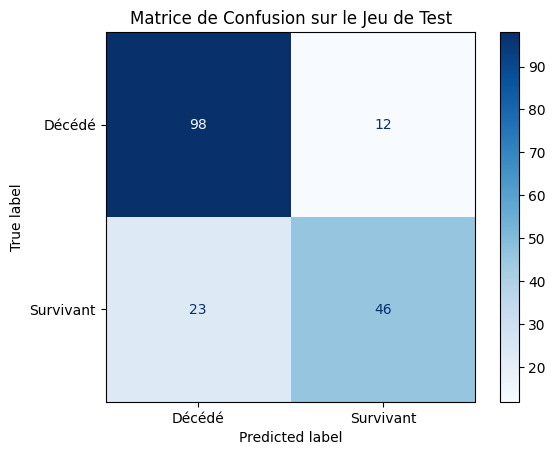

In [11]:
# Calcul des métriques
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Métriques de performance ---")
print(f"Exactitude (Accuracy)  : {acc:.2%}")
print(f"Précision              : {prec:.2%}")
print(f"Rappel (Recall)        : {rec:.2%}")
print(f"F1-Score               : {f1:.2%}")
print("-------------------------------\n")

# Affichage de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Décédé", "Survivant"])

disp.plot(cmap='Blues')
plt.title("Matrice de Confusion sur le Jeu de Test")
plt.grid(False)
plt.show()

## 11. Validation Croisée (Cross-Validation)

Pour valider la stabilité de notre modèle et vérifier qu'il ne souffre pas de surapprentissage (overfitting) ou de sous-apprentissage (underfitting), nous effectuons une validation croisée à 5 plis (K-Fold cross-validation, `cv=5`). Le dataset complet $X$ est découpé en 5 parties égales, et chaque partie sert de jeu de test à tour de rôle.

In [12]:
# Pour la validation croisée, on applique le StandardScaler à l'ensemble du dataset
X_scaled_all = scaler.fit_transform(X)

# Calcul des scores de validation croisée
cv_scores = cross_val_score(model, X_scaled_all, y, cv=5, scoring='accuracy')

print("Scores obtenus pour chaque pli :", [f"{score:.2%}" for score in cv_scores])
print(f"Moyenne des scores de validation croisée : {cv_scores.mean():.2%}")
print(f"Écart-type des scores : {cv_scores.std():.2%}")

Scores obtenus pour chaque pli : ['77.09%', '78.65%', '78.09%', '76.97%', '82.02%']
Moyenne des scores de validation croisée : 78.57%
Écart-type des scores : 1.84%


## 12. Prédiction sur une nouvelle donnée

Simulons l'arrivée d'un nouveau passager mystère à bord du Titanic :
- Un homme âgé de 28 ans.
- Voyageant seul (0 frère/sœur/conjoint, 0 parent/enfant).
- Ayant payé un ticket de cabine en 3ème classe au prix moyen de 8.5$.
- Embarqué à Southampton.

Nous allons appliquer scrupuleusement la même structure, le même encodage, et le même transformateur `scaler` avant d'utiliser notre modèle pour prédire son sort.

In [13]:
# Création d'une nouvelle observation (DataFrame)
nouvelle_donnee = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['male'],
    'Age': [28.0],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [8.5],
    'Embarked': ['S']
})

# Encodage manuel structuré identique à l'entraînement
# Nous créons de manière explicite les colonnes générées par pd.get_dummies
nouvelle_donnee_encoded = pd.DataFrame({
    'Pclass': nouvelle_donnee['Pclass'],
    'Age': nouvelle_donnee['Age'],
    'SibSp': nouvelle_donnee['SibSp'],
    'Parch': nouvelle_donnee['Parch'],
    'Fare': nouvelle_donnee['Fare'],
    'Sex_male': [1 if nouvelle_donnee['Sex'].iloc[0] == 'male' else 0],
    'Embarked_Q': [1 if nouvelle_donnee['Embarked'].iloc[0] == 'Q' else 0],
    'Embarked_S': [1 if nouvelle_donnee['Embarked'].iloc[0] == 'S' else 0]
})

# S'assurer de l'ordre identique des colonnes que dans X
nouvelle_donnee_encoded = nouvelle_donnee_encoded[X.columns]

# Standardisation
nouvelle_donnee_scaled = scaler.transform(nouvelle_donnee_encoded)

# Prédiction finale
pred_res = model.predict(nouvelle_donnee_scaled)[0]
pred_proba = model.predict_proba(nouvelle_donnee_scaled)[0]

print("Résultat de la prédiction :")
if pred_res == 1:
    print(f"Le passager est prédit comme SURVIVANT (probabilité de {pred_proba[1]:.2%}).")
else:
    print(f"Le passager est prédit comme NON-SURVIVANT (probabilité de décès de {pred_proba[0]:.2%}).")

Résultat de la prédiction :
Le passager est prédit comme NON-SURVIVANT (probabilité de décès de 91.14%).
